# Neural Network (MLP) with NumPy — OOP Implementation

Object-oriented MLP with arbitrary depth, multiple activations, He/Xavier init,
mini-batch gradient descent, momentum, and L2 regularisation.

**Architecture:** `Input(30) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(1, Sigmoid)`  
**Dataset:** Breast Cancer  
**Model saved to:** `../Models/nn_numpy.npz`

## 1. Load & Prepare Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

data     = load_breast_cancer()
X_raw, y = data.data, data.target.reshape(-1, 1).astype(np.float64)
class_names = list(data.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0) + 1e-8
X_train_sc = (X_train - X_mean) / X_std
X_test_sc  = (X_test  - X_mean) / X_std

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}  |  Features: {X_raw.shape[1]}")

Train: 455  |  Test: 114  |  Features: 30


## 2. Activation Functions

In [2]:
def relu(z):           return np.maximum(0, z)
def relu_grad(z):      return (z > 0).astype(float)

def sigmoid(z):        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def sigmoid_grad(z):   s = sigmoid(z); return s * (1 - s)

def tanh_act(z):       return np.tanh(z)
def tanh_grad(z):      return 1 - np.tanh(z) ** 2

ACTIVATIONS = {
    'relu':    (relu,     relu_grad),
    'sigmoid': (sigmoid,  sigmoid_grad),
    'tanh':    (tanh_act, tanh_grad),
}

## 3. Dense Layer

In [3]:
class Dense:
    """
    Fully-connected layer with one activation function.
    Stores forward-pass cache for backprop.
    """
    def __init__(self, n_in, n_out, activation='relu', seed=None):
        rng = np.random.default_rng(seed)
        self.activation, self.grad_fn = ACTIVATIONS[activation]
        self.act_name = activation

        # He init for relu, Xavier for sigmoid/tanh
        scale = np.sqrt(2 / n_in) if activation == 'relu' else np.sqrt(1 / n_in)
        self.W = rng.standard_normal((n_in, n_out)) * scale
        self.b = np.zeros((1, n_out))

        # Momentum buffers (used by SGD+momentum or Adam)
        self.vW = np.zeros_like(self.W)
        self.vb = np.zeros_like(self.b)
        self.mW = np.zeros_like(self.W)   # Adam first moment
        self.mb = np.zeros_like(self.b)

        self.cache = {}    # stores (X, Z) for backprop
        self.dW = None
        self.db = None

    def forward(self, X):
        Z = X @ self.W + self.b
        A = self.activation(Z)
        self.cache = {'X': X, 'Z': Z}
        return A

    def backward(self, dA, l2_lambda=0.0):
        """dA: gradient of loss w.r.t. this layer's output."""
        X, Z = self.cache['X'], self.cache['Z']
        n    = len(X)

        dZ       = dA * self.grad_fn(Z)        # apply activation gate
        self.dW  = X.T @ dZ / n + l2_lambda * self.W   # L2 penalty on W
        self.db  = dZ.sum(axis=0, keepdims=True) / n
        dX       = dZ @ self.W.T               # gradient to pass upstream
        return dX

    def __repr__(self):
        return f"Dense({self.W.shape[0]}→{self.W.shape[1]}, {self.act_name})"

## 4. MLP (Network)

In [4]:
class MLP:
    """
    Multi-Layer Perceptron — arbitrary depth.
    Supports SGD, SGD+Momentum, Adam optimisers.
    """
    def __init__(self, layers):
        self.layers = layers

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, y_pred, y_true, l2_lambda=0.0):
        n   = len(y_true)
        # Gradient of BCE + sigmoid at output layer
        dA  = (y_pred - y_true) / n
        # The output Dense backward applies sigmoid_grad internally;
        # but BCE+sigmoid simplifies to (y_hat - y)/n at the pre-activation.
        # We skip the sigmoid_grad here by passing dA directly as dZ.
        # Implement this by passing dA as if grad_fn=1 for the last layer.
        last = self.layers[-1]
        X, Z = last.cache['X'], last.cache['Z']
        last.dW = X.T @ dA / n + l2_lambda * last.W
        last.db = dA.sum(axis=0, keepdims=True) / n
        dA_prev = dA @ last.W.T

        for layer in reversed(self.layers[:-1]):
            dA_prev = layer.backward(dA_prev, l2_lambda)

    def update_sgd(self, lr):
        for layer in self.layers:
            layer.W -= lr * layer.dW
            layer.b -= lr * layer.db

    def update_momentum(self, lr, mu=0.9):
        for layer in self.layers:
            layer.vW = mu * layer.vW - lr * layer.dW
            layer.vb = mu * layer.vb - lr * layer.db
            layer.W += layer.vW
            layer.b += layer.vb

    def update_adam(self, lr, t, beta1=0.9, beta2=0.999, eps=1e-8):
        for layer in self.layers:
            layer.mW = beta1 * layer.mW + (1 - beta1) * layer.dW
            layer.mb = beta1 * layer.mb + (1 - beta1) * layer.db
            layer.vW = beta2 * layer.vW + (1 - beta2) * layer.dW ** 2
            layer.vb = beta2 * layer.vb + (1 - beta2) * layer.db ** 2
            mW_hat = layer.mW / (1 - beta1 ** t)   # bias correction
            mb_hat = layer.mb / (1 - beta1 ** t)
            vW_hat = layer.vW / (1 - beta2 ** t)
            vb_hat = layer.vb / (1 - beta2 ** t)
            layer.W -= lr * mW_hat / (np.sqrt(vW_hat) + eps)
            layer.b -= lr * mb_hat / (np.sqrt(vb_hat) + eps)

    def total_params(self):
        return sum(l.W.size + l.b.size for l in self.layers)

    def __repr__(self):
        return 'MLP(\n  ' + '\n  '.join(str(l) for l in self.layers) + '\n)'

## 5. Training Loop with Mini-Batch GD + Adam

In [5]:
def bce(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def train(model, X_train, y_train, X_val, y_val,
          epochs=300, lr=1e-3, batch_size=32,
          l2_lambda=1e-4, optimiser='adam', verbose=True):

    n = len(X_train)
    t = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # Shuffle each epoch
        idx = np.random.permutation(n)
        X_shuf, y_shuf = X_train[idx], y_train[idx]

        # Mini-batch updates
        for start in range(0, n, batch_size):
            Xb = X_shuf[start:start + batch_size]
            yb = y_shuf[start:start + batch_size]
            t += 1

            y_hat = model.forward(Xb)
            model.backward(y_hat, yb, l2_lambda)

            if optimiser == 'adam':     model.update_adam(lr, t)
            elif optimiser == 'momentum': model.update_momentum(lr)
            else:                        model.update_sgd(lr)

        # Epoch metrics
        y_tr_hat = model.forward(X_train)
        y_va_hat = model.forward(X_val)
        history['train_loss'].append(bce(y_train, y_tr_hat))
        history['val_loss'].append(bce(y_val,   y_va_hat))
        history['train_acc'].append(np.mean((y_tr_hat >= 0.5) == y_train))
        history['val_acc'].append(np.mean((y_va_hat >= 0.5) == y_val))

        if verbose and (epoch % 50 == 0 or epoch == 1):
            print(f"Epoch {epoch:>4} | loss: {history['train_loss'][-1]:.4f} "
                  f"| val_loss: {history['val_loss'][-1]:.4f} "
                  f"| val_acc: {history['val_acc'][-1]:.4f}")

    return history


# Build network
np.random.seed(42)
model = MLP([
    Dense(30, 64, activation='relu',    seed=0),
    Dense(64, 32, activation='relu',    seed=1),
    Dense(32,  1, activation='sigmoid', seed=2),
])
print(model)
print(f"Total parameters: {model.total_params():,}")

MLP(
  Dense(30→64, relu)
  Dense(64→32, relu)
  Dense(32→1, sigmoid)
)
Total parameters: 4,097


In [6]:
history = train(model, X_train_sc, y_train, X_test_sc, y_test,
                epochs=300, lr=1e-3, batch_size=32,
                l2_lambda=1e-4, optimiser='adam')

Epoch    1 | loss: 0.3621 | val_loss: 0.4037 | val_acc: 0.8246
Epoch   50 | loss: 0.0232 | val_loss: 0.1012 | val_acc: 0.9474
Epoch  100 | loss: 0.0139 | val_loss: 0.0936 | val_acc: 0.9649
Epoch  150 | loss: 0.0093 | val_loss: 0.0962 | val_acc: 0.9561
Epoch  200 | loss: 0.0087 | val_loss: 0.0921 | val_acc: 0.9561
Epoch  250 | loss: 0.0079 | val_loss: 0.0955 | val_acc: 0.9649
Epoch  300 | loss: 0.0076 | val_loss: 0.0969 | val_acc: 0.9561


## 6. Loss & Accuracy Curves

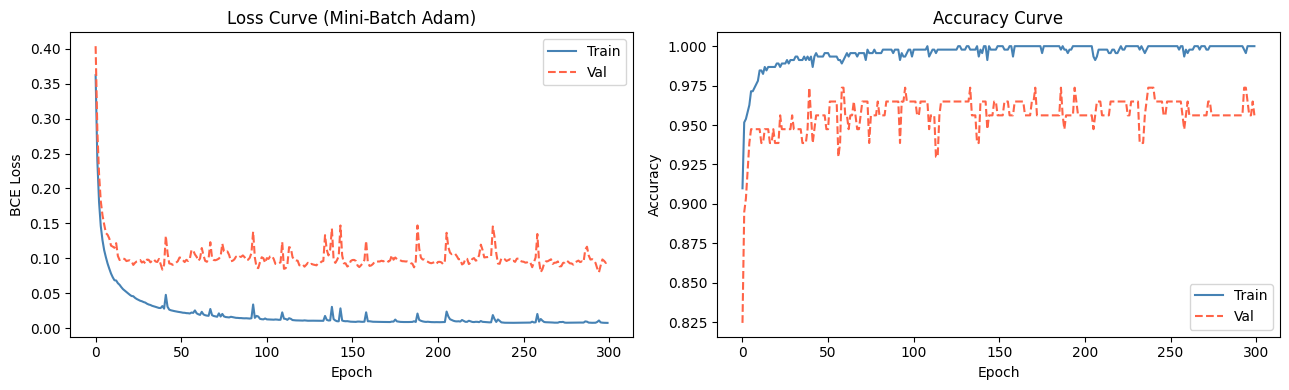

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history['train_loss'], label='Train', color='steelblue')
ax1.plot(history['val_loss'],   label='Val',   color='tomato', linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss Curve (Mini-Batch Adam)'); ax1.legend()

ax2.plot(history['train_acc'], label='Train', color='steelblue')
ax2.plot(history['val_acc'],   label='Val',   color='tomato', linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve'); ax2.legend()

plt.tight_layout(); plt.show()

## 7. Evaluation

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC-AUC: 0.9940


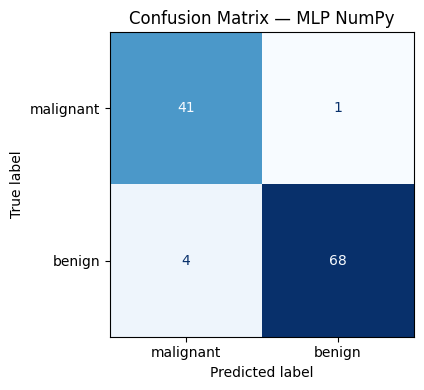

In [8]:
y_proba = model.forward(X_test_sc).flatten()
y_pred  = (y_proba >= 0.5).astype(int)

print(classification_report(y_test.flatten(), y_pred, target_names=class_names))
print(f"ROC-AUC: {roc_auc_score(y_test.flatten(), y_proba):.4f}")

cm   = confusion_matrix(y_test.flatten(), y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — MLP NumPy')
plt.tight_layout(); plt.show()

## 8. Optimiser Comparison (SGD vs Momentum vs Adam)

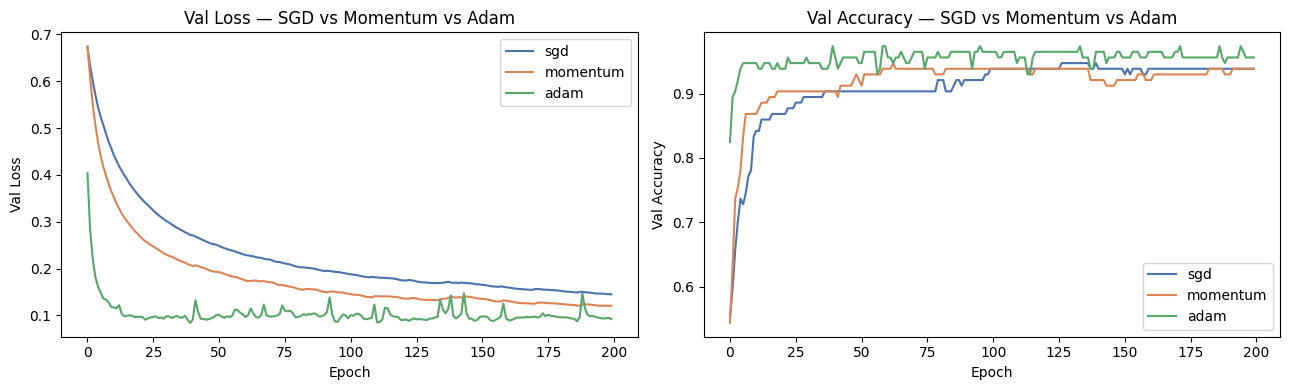

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = {'sgd': '#4C72B0', 'momentum': '#DD8452', 'adam': '#55A868'}

for opt, lr in [('sgd', 0.05), ('momentum', 0.01), ('adam', 1e-3)]:
    np.random.seed(42)
    m = MLP([
        Dense(30, 64, 'relu', seed=0),
        Dense(64, 32, 'relu', seed=1),
        Dense(32,  1, 'sigmoid', seed=2),
    ])
    h = train(m, X_train_sc, y_train, X_test_sc, y_test,
              epochs=200, lr=lr, batch_size=32, optimiser=opt, verbose=False)
    axes[0].plot(h['val_loss'], label=opt, color=colors[opt])
    axes[1].plot(h['val_acc'],  label=opt, color=colors[opt])

for ax, title in zip(axes, ['Val Loss', 'Val Accuracy']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.set_title(f'{title} — SGD vs Momentum vs Adam')
    ax.legend()
plt.tight_layout(); plt.show()

## 9. Effect of L2 Regularisation

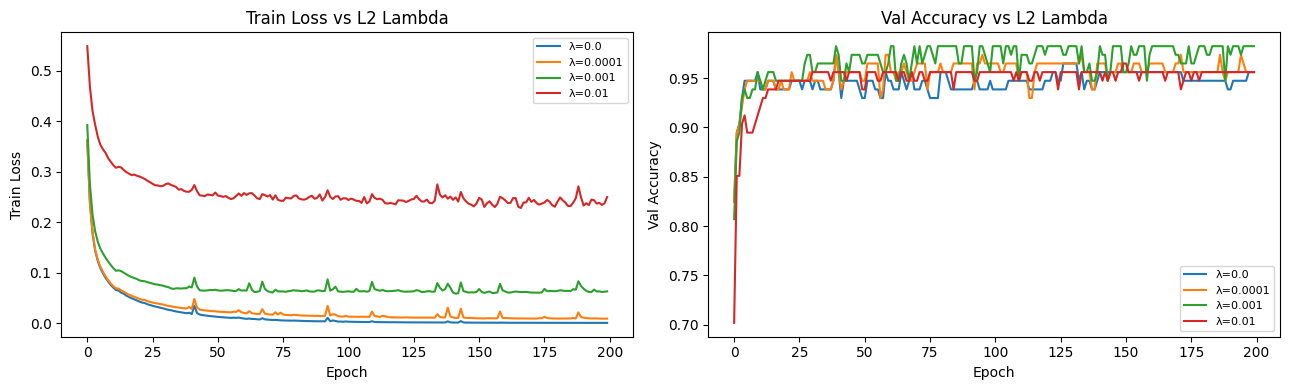

In [10]:
l2_values = [0.0, 1e-4, 1e-3, 1e-2]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for lam in l2_values:
    np.random.seed(42)
    m = MLP([Dense(30,64,'relu',seed=0), Dense(64,32,'relu',seed=1), Dense(32,1,'sigmoid',seed=2)])
    h = train(m, X_train_sc, y_train, X_test_sc, y_test,
              epochs=200, lr=1e-3, l2_lambda=lam, optimiser='adam', verbose=False)
    axes[0].plot(h['train_loss'], label=f'λ={lam}')
    axes[1].plot(h['val_acc'],    label=f'λ={lam}')

for ax, title in zip(axes, ['Train Loss', 'Val Accuracy']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.set_title(f'{title} vs L2 Lambda')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10. Save Model to `../Models/`

In [11]:
weights = {f'W{i}': l.W for i, l in enumerate(model.layers)}
biases  = {f'b{i}': l.b for i, l in enumerate(model.layers)}

np.savez_compressed('../Models/nn_numpy.npz',
    x_mean=X_mean, x_std=X_std,
    n_layers=np.array(len(model.layers)),
    **weights, **biases
)
print(f"Saved → ../Models/nn_numpy.npz  "
      f"({os.path.getsize('../Models/nn_numpy.npz')/1024:.1f} KB)")

Saved → ../Models/nn_numpy.npz  (33.0 KB)
